# GM-CDLD discovery and frozen reuse
Main manuscript: 32D, 20 cycles, 20 reader epochs, seeds 17/43/97. This calls the original training implementation, not a reimplementation. One NBA cycle presents each row 10 times; tennis 4. Initial comparison is not part of this workflow.

Set the prepared input path before running. Full training can take hours. Stored outputs were generated by executing this notebook on 30 September 2026.

In [1]:
from pathlib import Path
import json, subprocess, sys, shutil
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
assert (ROOT/'code/train.py').is_file(), 'Open from repository root or notebooks/'
print('Repository:', ROOT.name)
def run_command(args, cwd=None, check=True):
    """Stream subprocess output into the notebook, preserving failures."""
    proc = subprocess.Popen(args, cwd=cwd, stdout=subprocess.PIPE,
                            stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in proc.stdout:
        print(line.replace(str(ROOT), '.'), end='', flush=True)
    code = proc.wait()
    if check and code:
        raise RuntimeError(f'Command failed with exit code {code}')



Repository: GM-CDLD


In [2]:
DATA = ROOT/'work/prepared/data'  # provide NBA/ and tennis/ here
RUN = ROOT/'work/manuscript_run'  # must be a NEW directory
DOMAINS = ['NBA','tennis']
CONDITIONS = ['direct']  # GM; optionally add 'C39' for the supplementary readout variant
SEEDS = [17,43,97]

In [3]:
run_command([sys.executable,str(ROOT/'tools/stage_run.py'),'--data',str(DATA),'--output',str(RUN)],check=True)
cfg=json.loads((RUN/'plan.json').read_text())
cfg.update(domains=DOMAINS,conditions=CONDITIONS,seeds=SEEDS)
(RUN/'plan.json').write_text(json.dumps(cfg,indent=2))
print(cfg)

Staged only: ./work/manuscript_run. Training has not started.


{'frozen_at': '2026-09-22T07:38:02.284637+00:00', 'seeds': [17, 43, 97], 'domains': ['NBA', 'tennis'], 'conditions': ['direct'], 'cycles': 20, 'epochs': 20, 'latent_dim': 32, 'batch': 64, 'lr': 0.0003, 'l2': 0.001, 'head': [64, 16], 'row_adam': 'reset each visit', 'finder_adam': 'persistent independent A/B', 'initial_latent': 'new seed-specific Glorot uniform shared across conditions', 'selection': 'fit game count >=10 NBA/>=20 tennis, one pass filtering, retain only all-member-eligible rows; training-unobserved members excluded from final evaluation', 'NBA': {'fit': 'existing C31 fit, not D validation', 'development': 'existing validation not final', 'final': 'existing E games 2024-03-14 through 2024-04-14', 'targets': ['points', 'assists', 'turnovers', 'offensive_rebounds'], 'context': 'existing home/period/start elapsed/start differential; fit scaling', 'source_loss': 'MSE on fit standardized points', 'weight': 1}, 'tennis': {'years': [2017, 2018, 2019], 'split': 'sorted tourney_id 

## Inspect the executed implementation
Finder selects one member and resets its Adam moments; only that latent and the active network are updated. Reader latents are constants. The code printed here is the code invoked below.

In [4]:
print((RUN/'train.py').read_text())

"""C42 fixed protocol. Train only; final held-out arrays are loaded by evaluate.py.
Graph player visits preserve sequential Adam updates while reducing host overhead.
"""
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL','3');os.environ.setdefault('TF_DETERMINISTIC_OPS','1');os.environ.setdefault('TF_ENABLE_ONEDNN_OPTS','0')
import argparse,json,time,traceback,fcntl
from pathlib import Path
import numpy as np
import tensorflow as tf
W=Path(__file__).resolve().parent;P=json.loads((W/'plan.json').read_text());D=P['latent_dim'];B=P['batch']
tf.config.threading.set_intra_op_parallelism_threads(2);tf.config.threading.set_inter_op_parallelism_threads(2)
tf.config.experimental.enable_tensor_float_32_execution(False)
for gpu in tf.config.list_physical_devices('GPU'):tf.config.experimental.set_memory_growth(gpu,True)
def seedval(*v):return int(np.random.SeedSequence(v).generate_state(1)[0]%2147483647)
def js(path,data):
 path=Path(path);path.parent.mkdir(parents=True,exist_ok=True);tmp=pat

## Train
Each subprocess prints fit losses. Checkpoints and per-batch/epoch loss arrays are written under runs/. Existing completed jobs are skipped on resume. Do not rerun the staging cell to resume.

In [5]:
run_command([sys.executable,str(RUN/'run_all.py'),'--execute','--jobs','2'],cwd=RUN,check=True)

START NBA_direct_17


START NBA_direct_43


DONE NBA_direct_17


START NBA_direct_97


DONE NBA_direct_43


...

START tennis_direct_97_target_df_rate


DONE tennis_direct_97_target_ace_rate


START tennis_direct_97_target_service_win_rate


DONE tennis_direct_97_target_df_rate


DONE tennis_direct_97_target_service_win_rate


## Plot stored fit trajectories
This historical fixed-budget protocol has no validation selection; do not substitute a later validation-based model.

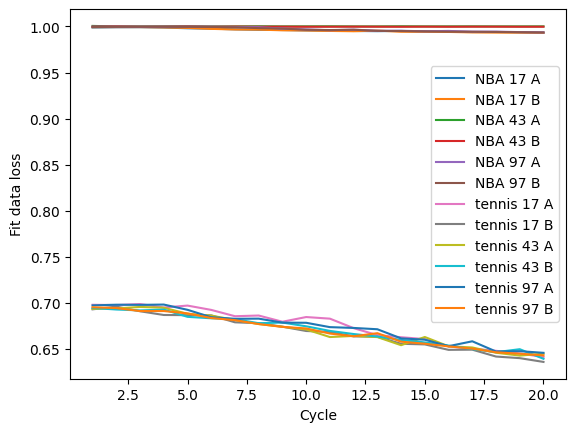

In [6]:
import matplotlib.pyplot as plt
for d in DOMAINS:
    for seed in SEEDS:
        folder=RUN/'runs'/d/'direct'/f'seed_{seed}'/'finder'
        rows=[json.loads(p.read_text()) for p in sorted(folder.glob('phase_[0-9][0-9].json'))]
        for side in ['A','B']:
            q=[r for r in rows if r['side']==side]
            plt.plot([r['cycle'] for r in q],[r['fit_loss'][side] for r in q],label=f'{d} {seed} {side}')
plt.xlabel('Cycle');plt.ylabel('Fit data loss');plt.legend();plt.show()